# Machine Learning Assignement 2
Authors : Muzaffar Izamuddin, Haniy Turana, Ahmad Mujahid <br>
Student ID: P166246, P166239, P166974

## 1.0 Introduction

## 2.0 Part A: Exploratory Analysis and Class Distribution

We begin by going through the assigned dataset.

**Dataset description**

- Source file: `ASSG22026.csv`
- Observations: 1500
- Features: 15 numeric features named `feature_1` through `feature_15`
- Target: binary `target` column with imbalanced classes

This dataset appears to be a supervised binary classification problem with all numeric predictors. The target column is the event of interest, and initial exploration should focus on how frequently each class occurs and whether the dataset is strongly skewed toward one label.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


sns.set(style='whitegrid')

# Load the dataset
file_path = 'ASSG22026.csv'
df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nTarget value counts:')
print(df['target'].value_counts(dropna=False))

# Show the first few rows
print('\nFirst five rows:')
print(df.head())

Dataset shape: (1500, 16)

Columns: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'target']

Target value counts:
target
0    1420
1      80
Name: count, dtype: int64

First five rows:
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   1.286759  -3.452735  -0.595082   2.852650   5.289887  -0.366363   
1  -0.445937  -4.098332  -0.678555   0.242937   4.107822  -1.645675   
2   1.654022  -1.064226  -1.480801  -0.719527   2.978319   0.482093   
3  -2.432039   3.309322  -0.458722  -1.967034  -4.950714   0.108292   
4  -1.084632   1.105736  -0.208542   0.297446  -1.669344   0.609055   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0   4.533496   0.347942   0.717730   -0.645499    5.186470    0.202211   
1   4.933900  -0.415859   0.107588   -1.912968    3.911879    1.950317   
2  -1.0543

the dataset contains an supervised binary classification problem with  1,500 observation and 15 numeric predictors (feature 1 through feature 15).

* Class 0 (Majority / Non-Event): 1,420 instances (95%)
* Class 1 (Minority / Critical Event): 80 instances (5%)

C:\Users\PC 14\AppData\Local\Temp\ipykernel_17804\2105068031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


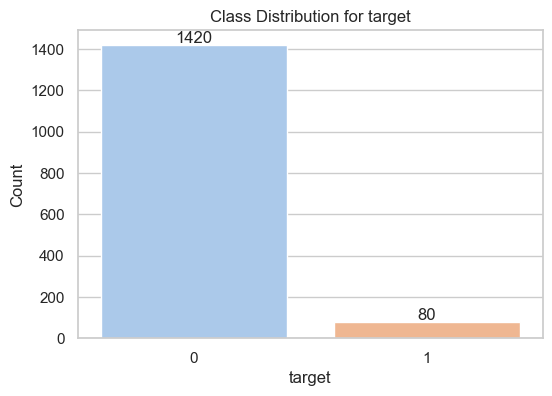

In [ ]:
# Visualize the class distribution for the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='pastel')
plt.title('Class Distribution for target')
plt.xlabel('target')
plt.ylabel('Count')

counts = df['target'].value_counts().sort_index()
for index, value in enumerate(counts):
    plt.text(index, value + 10, str(value), ha='center')

plt.show()

What happens when there is and imbalance class and class 1 is a minority?

- Many classifiers will favor the majority class, especially when trained with default settings. This can lead to models that predict the majority label most of the time and fail to detect the minority event.
- A high overall accuracy is possible even if the model never correctly predicts the rare class. For example, if the minority class is only 5%, a model that always predicts the majority class still achieves 95% accuracy.
- Imbalanced data often leads to low recall for the rare class, which is problematic when the rare event is the one we most care about (fraud, disease, failure, etc.).
- Metrics such as precision, recall, F1-score, and AUC are more informative than accuracy for imbalanced classification. They help show how well the model identifies the minority class and balances false positives against false negatives.
- Handling imbalance explicitly through resampling methods, algorithmic class weights, cost-sensitive learning, or threshold adjustment is usually necessary to build a reliable predictive model for this dataset.

### 2.1 Perform PCA Analysis 
- We would like to identify if the class minority (class 1) and majority (class 2) is overlapped in main component or if there is any cluster

In [5]:
RANDOM_STATE = 42
X = df.drop(columns='target')
y = df['target']

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

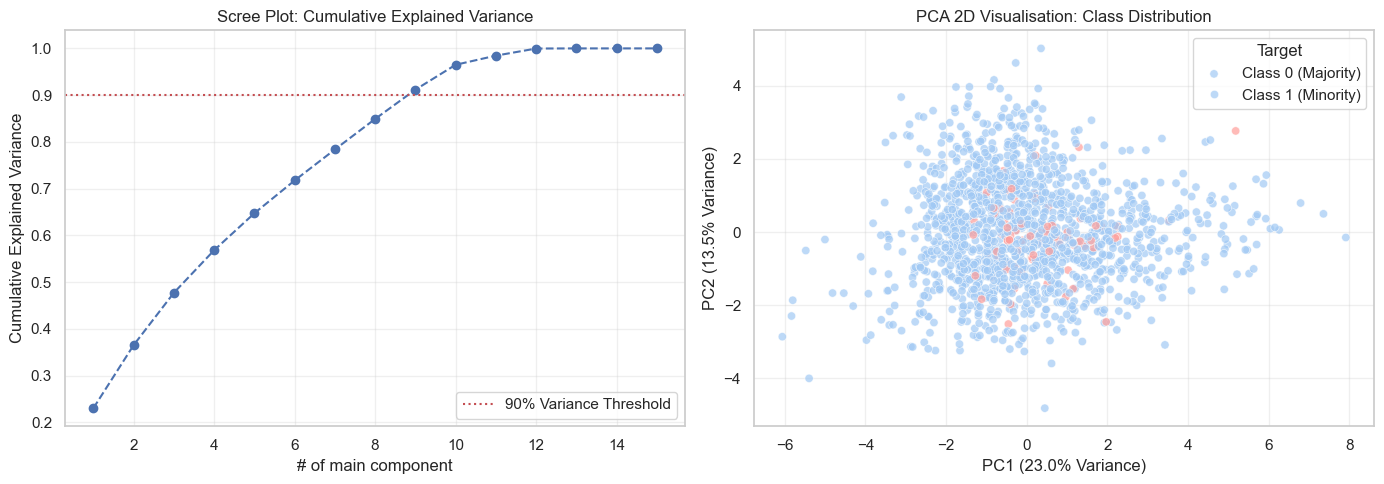

In [6]:
# Transform data to 2 main component (PC1 & PC2) to visualize 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
df_pca['target'] = y.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Scree Plot (Explained Variance)
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
axes[0].axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
axes[0].set_title('Scree Plot: Cumulative Explained Variance')
axes[0].set_xlabel('# of main component')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Plot B: 2D PCA Scatter Plot (Class Separation)
sns.scatterplot(
    x='PC1', y='PC2',
    hue='target',
    data=df_pca,
    palette={0: '#a1c9f4', 1: '#ff9f9b'}, # Warna pastel yang kontras
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('PCA 2D Visualisation: Class Distribution')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[1].legend(title='Target', labels=['Class 0 (Majority)', 'Class 1 (Minority)'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Result interpretation: Principal Component Analysis (PCA) 

To deeply understand the geometric structure of the dataset and uncover the underlying patterns of the severe 94.7% to 5.3% class imbalance, a Principal Component Analysis (PCA) was conducted after standardizing the features. 

#### 2.2.1. Dimensionality and Variance Analysis (Scree Plot)
The left plot Scree Plot illustrates the cumulative explained variance across the extracted principal components:

- Information Dispersion: The dataset’s variance is highly distributed across multiple dimensions rather than being concentrated in just one or two features. 
- Variance Threshold: The first two principal components (PC1 and PC2) combined explain only 36.5% of the total variance (PC1 = 23.0%, PC2 = 13.5%). 
- Dimensionality Reduction: To capture 90% of the dataset's original information (the red dotted threshold), at least 9 principal components are required.
- This indicates that the dataset contains complex, multi-dimensional feature interactions that cannot be easily simplified into a simple 2D representation without significant information loss.

#### 2.2.2. Geometric Class Separation (2D Scatter Plot)
- The right plot PCA 2D Visualisation projects the entire dataset into the coordinates of the first two principal components, mapping the distribution of the majority class (Class 0) against the minority event (Class 1).
- The minority samples (represented by the orange/red dots) do not form a separate cluster or sub-pocket. Instead, they are completely embedded and submerged within the dense cloud of the majority class (blue dots).
- There is no distinct spatial boundary or clear linear hyperplane that can split the two target classes. The data structure is heavily non-linearly separable.

#### 2.2.3. Modeling Implications
- This complete geometric overlap is precisely why our baseline models become blind to the minority class.
- The model would treated these  rare events as negligible noise to maximize overall performance on the majority class.
- Because a straight linear boundary or a standard tree split cannot separate these classes in their current state, advanced interventions—such as synthesizing minority spaces (SMOTE), imposing heavy misclassification penalties (Class Weights), and isolating local feature pockets (Balanced Bagging)—are an absolute necessity to break this blind spot.



### 3.0 Part B: Baseline Model

This section trains baseline models on the original imbalanced dataset. No oversampling, undersampling, SMOTE, class weighting, or threshold adjustment is applied here, so these results can be used as the reference point for Part C.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Training class distribution:')
print(y_train.value_counts().sort_index())
print('\nTesting class distribution:')
print(y_test.value_counts().sort_index())

Training class distribution:
target
0    1136
1      64
Name: count, dtype: int64

Testing class distribution:
target
0    284
1     16
Name: count, dtype: int64


#### 3.1 Baseline Model Training (Logistic Regression and Decision Tree)

- Logistic regression is trained with feature scaling because it is sensitive to feature magnitude.
- Decision tree is trained directly on the numeric features because tree splits are scale-invariant.
- Both models use default class treatment, so the original 0/1 imbalance remains unchanged.

In [8]:
baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
}


def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
    }


baseline_results = [
    evaluate_classifier(name, model, X_train, X_test, y_train, y_test)
    for name, model in baseline_models.items()
]

baseline_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions']}
    for result in baseline_results
])

baseline_metrics.round(4)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.9500,1.0,0.0625,0.1176,0.7771
1,Decision Tree,0.9367,0.4,0.3750,0.3871,0.6717


### 3.2 Baseline Models Evaluation

- Logistic Regression model is trained with Feature Scaling (`StandardScaler`) because the algorithm optimizes weights via Gradient Descent and is highly sensitive to different feature magnitudes.
- Decision Tree is trained directly on raw data because tree splits rely on rank-based thresholds and are completely scale-invariant.
- Both models use default settings, meaning the extreme 95:5 class imbalance remains completely unadjusted to show how the models would naturally perform.

| Model | Accuracy | Precision | Recall | F1-score | AUC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | 0.95 | 1.0 | 0.06 | 0.12 | 0.78 |
| **Decision Tree** | 0.94 | 0.4 | 0.38 | 0.39 | 0.68 |

*(Result from the `baseline_metrics`)*


- Both models display a very high **Accuracy (at least 94%)**. In traditional balanced data, this would suggest an excellent model fit, but here it is a completely misleading vanity metric.
- The dataset consists of 95% Class 0. A completely naive classifier can easily achieve ~95% accuracy simply by biasing its decision boundary toward the majority class and predicting "0" for almost every row.
- The real failure of the models is exposed by the **drastically low Recall and F1-score** for the minority class (Class 1).
- The models are failing to detect the actual critical rare events, which proves that traditional accuracy cannot be trusted as a baseline measure of success for this deployment.

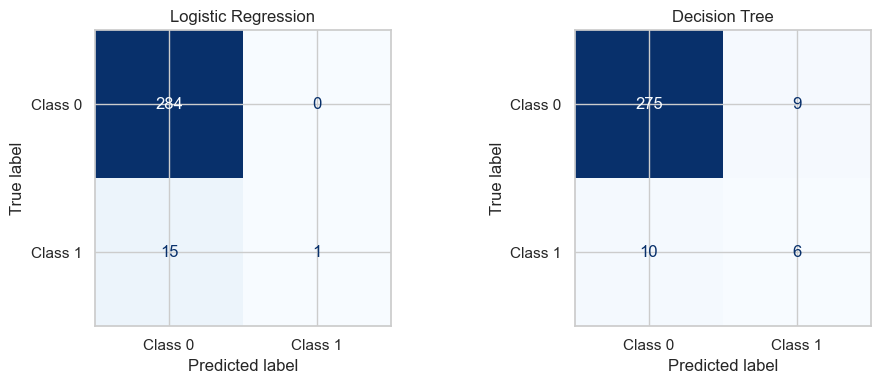

In [9]:
#performing the confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, baseline_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(result['Model'])

plt.tight_layout()
plt.show()

### 3.3 Confusion Matrix on the Baseline Models

- The matrices provide empirical proof of algorithmic bias caused by the 95:5 class imbalance.
- Logistic Regression has detected only **1 out of 16** actual Class 1 events, completely **missing 15 instances** as False Negatives. This causes a critically low Recall rate.
- Decision Tree has detected only **6 out of 16** actual Class 1 events, **misclassifying 10 critical instances** as Class 0 (False Negatives), while introducing 9 False Positives.
- Both baseline models bias their decision boundaries heavily toward Class 0 to maximize global accuracy, effectively treating the critical rare events as statistical noise.

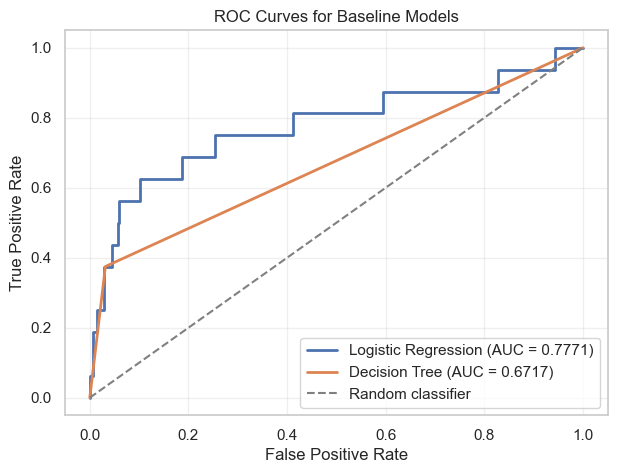

In [10]:
# Plot ROC curves for both baseline models and display AUC values
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))

for model_name, model in baseline_models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.title('ROC Curves for Baseline Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### 3.4 ROC Curve Interpretation

- The ROC curves show how well the models can actually separate the two classes regardless of the default 0.5 threshold we have.
- The model Logistic Regression has a higher ROC Score even though its baseline Recall was lower.
- It indicates that the model has a strong underlying ability to separate Class 1 from Class 0.
- So, if we adjust the threshold or add weights later, the performance will significantly improve.
- Although the AUC Score for Decision Tree is lower, the curve is very closs to the random classifier line.
- It indicates that the model has a poor generalization on the data because the tree splits are heavily influenced by the majority class.
- In conclusion, the Logistic Regression model is better model in this dataset because it ability to distinguish the rare events once we fix the class imbalance problem.

### 3.5 Part B Discussion

The baseline results show why accuracy can be misleading for this imbalanced problem. The test set contains 284 majority-class observations and only 16 minority-class observations. Logistic regression achieves about 95% accuracy, but its recall for the minority class is only 0.0625, meaning it correctly detects only 1 out of 16 minority cases. Its high accuracy mainly comes from correctly predicting the majority class.

The decision tree has slightly lower accuracy at about 93.67%, but it identifies 6 out of 16 minority cases, giving a better recall and F1-score than logistic regression. This makes the decision tree the stronger baseline if detecting the minority event is more important than simply maximizing overall accuracy.

Hence on the Part C, the decision tree can be treated as the selected baseline model to improve with imbalance-handling methods, while logistic regression remains useful as a comparison point.

## 4.0 Part C: Addressing Imbalance with SMOTE

### 4.1 Addressing Imbalance with SMOTE

SMOTE, or Synthetic Minority Oversampling Technique, handles class imbalance by generating synthetic minority-class samples from the training data. Instead of simply duplicating existing minority observations, SMOTE creates new points between nearby minority examples. This gives the model more minority-class patterns to learn from while keeping the test set untouched for fair evaluation.

For this experiment, the **Decision Tree** is retrained because it was the stronger baseline model in Part B for detecting the minority class. Logistic Regression is also retrained with SMOTE as an additional comparison, because SMOTE is a data-level method and can be used with any classifier after the training data is balanced.

In [11]:
# Import SMOTE. Install imbalanced-learn automatically if it is missing.
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

In [12]:
# Apply SMOTE only to the training data to avoid data leakage
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_distribution = pd.DataFrame({
    'Original training set': y_train.value_counts().sort_index(),
    'After SMOTE': y_train_smote.value_counts().sort_index(),
})

smote_distribution

,Original training set,After SMOTE
target,,
0,1136,1136
1,64,1136


In [13]:
# Retrain Logistic Regression and Decision Tree using SMOTE-balanced training data
smote_models = {
    'Logistic Regression': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
}

smote_results = []

for model_name, model in smote_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    smote_results.append({
        'Method': 'SMOTE',
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
        'Scores': y_score,
    })

smote_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions', 'Scores']}
    for result in smote_results
])

smote_metrics.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,SMOTE,Logistic Regression,0.7533,0.1375,0.6875,0.2292,0.7691
1,SMOTE,Decision Tree,0.9000,0.2812,0.5625,0.3750,0.7408


In [14]:
# Compare baseline results against SMOTE results for both models
baseline_comparison = baseline_metrics.copy()
baseline_comparison.insert(0, 'Method', 'Baseline')

smote_comparison = pd.concat(
    [baseline_comparison, smote_metrics],
    ignore_index=True,
)

smote_comparison.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline,Logistic Regression,0.9500,1.0000,0.0625,0.1176,0.7771
1,Baseline,Decision Tree,0.9367,0.4000,0.3750,0.3871,0.6717
2,SMOTE,Logistic Regression,0.7533,0.1375,0.6875,0.2292,0.7691
3,SMOTE,Decision Tree,0.9000,0.2812,0.5625,0.3750,0.7408


### 4.1.2 Baseline vs. SMOTE Model Performance

| Method | Model | Accuracy | Precision | Recall | F1-score | AUC |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Baseline** | Logistic Regression | **0.95** | **1.00** | 0.06 | 0.12 | **0.78** |
| **Baseline** | Decision Tree | 0.94 | 0.40 | 0.375 | **0.39** | 0.67 |
| **SMOTE** | Logistic Regression | 0.75 | 0.14 | **0.69** | 0.23 | 0.77 |
| **SMOTE** | Decision Tree | 0.90 | 0.28 | 0.56 | 0.378 | 0.74 |

- The Baseline Logistic Regression yields a deceptive accuracy of 95%. 
- However, because the test dataset remains highly imbalanced, accuracy is a misleading metric. 
- Hence, it achieve high accuracy simply by overwhelmingly predicting the majority class.
- By applying SMOTE drastically shifts model behavior.
- The Recall for Logistic Regression increased drastically from 6% to 69%, indicate it successfully captures the vast majority of the actual minority class.
- However, it reduced the Precision, which plummets from 100% down to 14%. 
- This indicates that SMOTE forces the models to become much more aggressive in predicting the minority class, resulting in a high volume of False Positives (false alarms).
- Meanwhile the Decision Tree handles SMOTE differently. 
- While its Recall improves significantly from 38% to 56, it manages to retain a much higher Accuracy of 90% and a better F1-score of 37.50% compared to the Logistic Regression. 
- It achived a more stable, well-rounded balance between Precision and Recall.
- Interestingly, Logistic Regression maintains the highest overall ability to distinguish between classes, with a Baseline AUC of 78% and a SMOTE AUC of 77%. 
- The Decision Tree, while visually more balanced in F1-score and AUC improve under SMOTE but still lags behind Logistic Regression in overall class separation.
---

- Therefore, the study would choose SMOTE + Logistic Regression if missing a positive case carries catastrophic consequences.
- This setup catches the most true minority instances 69% Recall and offers the highest overall discriminative power 77% AUC, despite generating many false alarms.
- While the study will choose SMOTE + Decision Tree if a reliable, operational model that limits false alarms is necessary.
- It offers a vastly superior balance at 38% F1-score and 28% Precision, by reducing the false positives while still capturing a reasonable portion of the minority class 56% Recall.

                                                                                     


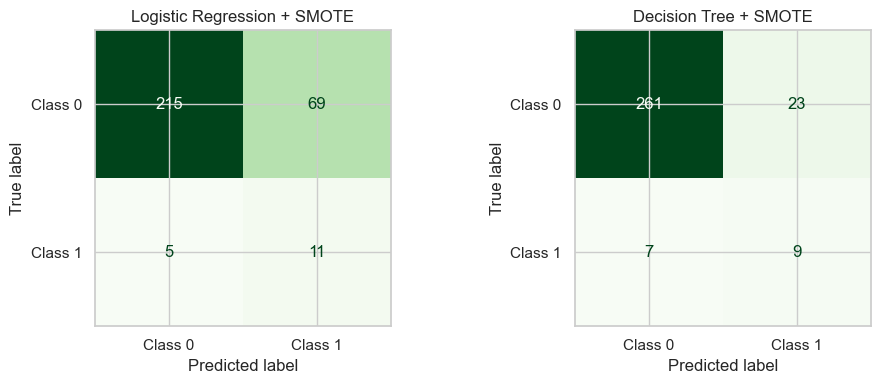

In [11]:
# Confusion matrices for both SMOTE-trained models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, smote_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(f"{result['Model']} + SMOTE")

plt.tight_layout()
plt.show()

### 4.1.3 Confusion Matrix for SMOTE-trained models

Based on the performance metrics and the confusion matrices shown above, here are the core findings of this study:

#### 1. The Impact of Class Imbalance & SMOTE
- The original, un-balanced data yielded a misleadingly high baseline accuracy of 95% because the models could simply over-predict the majority class (`Class 0`) while ignoring the minority class (`Class 1`).
- By applying SMOTE successfully fixed this blind spot for Logistic Regression, driving its Recall up to 69%.
- Hence, the models has correctly identifies 11 True Positives and only misses 5 False Negatives.
- However, this makes Logistic Regression highly aggressive. 
- It generates 69 False Positives (predicting `Class 1` when it is actually `Class 0`), which pulls its Precision down to 14%.

#### 2. Decision Tree's Balanced Behavior
- The Decision Tree model trained with SMOTE is much more conservative. 
- It cuts False Positives down drastically to just 23 cases.
- Because it minimizes these false alarms, it maintains a superior indicates by Precision of 28% (twice as precise as Logistic Regression) and a stronger overall F1-score of 38%, even though it misses slightly more minority instances because there are 7 False Negatives resulting by 56% Recall).

#### 3. Overall Discriminative Power (AUC)
- Despite the high number of false alarms, Logistic Regression + SMOTE still holds the highest overall ability to separate the two classes, maintaining an AUC of 77% compared to the Decision Tree's 74%.

---
- As usual, study should select SMOTE + Logistic Regression if missing a minority instance is highly critical.
- Because this model captures the highest volume of actual positive cases 69% Recall and provides the best overall class separation 77% AUC, meaning we accept the cost of handling more false alarms.
- Study should selectt SMOTE + Decision Tree if the operational objective is to deploy a balanced, reliable model that keeps false alarms to a minimum. 
- Because, it provides a vastly superior F1-score 38% and Precision 28%, ensuring the team isn't overwhelmed by costly false positives while still capturing a solid chunk of the minority class.


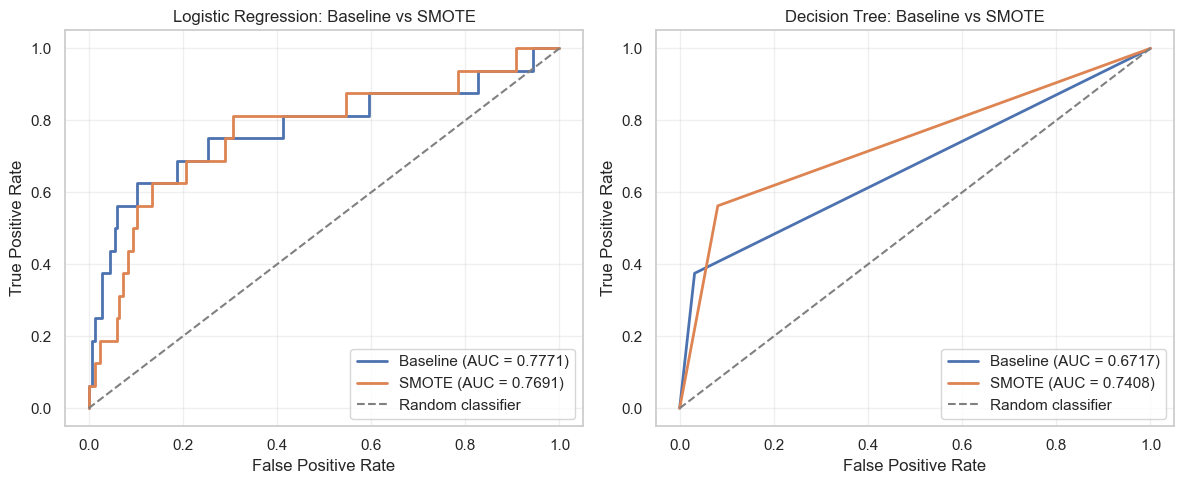

In [15]:
# ROC curve comparison: baseline vs SMOTE for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

roc_pairs = [
    ('Logistic Regression', axes[0]),
    ('Decision Tree', axes[1]),
]

for model_name, ax in roc_pairs:
    baseline_model = baseline_models[model_name]
    baseline_score = baseline_model.predict_proba(X_test)[:, 1]
    baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_score)
    baseline_auc = roc_auc_score(y_test, baseline_score)

    smote_model = smote_models[model_name]
    smote_score = smote_model.predict_proba(X_test)[:, 1]
    smote_fpr, smote_tpr, _ = roc_curve(y_test, smote_score)
    smote_auc = roc_auc_score(y_test, smote_score)

    ax.plot(
        baseline_fpr,
        baseline_tpr,
        linewidth=2,
        label=f'Baseline (AUC = {baseline_auc:.4f})',
    )
    ax.plot(
        smote_fpr,
        smote_tpr,
        linewidth=2,
        label=f'SMOTE (AUC = {smote_auc:.4f})',
    )
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
    ax.set_title(f'{model_name}: Baseline vs SMOTE')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1.4 ROC Curve Interpretation (Smote vs Baseline)

The comparison table shows that SMOTE improves minority-class recall for both models, but it also increases false positives. Logistic Regression changes the most: recall improves from **0.0625** to **0.6875**, meaning it detects 11 out of 16 minority cases instead of only 1. However, precision drops from **1.0000** to **0.1375** and accuracy falls from **0.9500** to **0.7533**, because the model now predicts many more minority cases.

For the Decision Tree, SMOTE improves recall from **0.3750** to **0.5625** and AUC from **0.6717** to **0.7408**. Accuracy decreases from **0.9367** to **0.9000**, and precision decreases from **0.4000** to **0.2813**. This is a smaller trade-off than Logistic Regression while still improving detection of the minority class.

Overall, SMOTE is useful when the deployment goal is to catch more minority events, even at the cost of more false alarms. Among the two SMOTE models, Logistic Regression gives the highest recall, while the SMOTE Decision Tree gives a more balanced trade-off between recall, precision, accuracy, and AUC.

### 4.2 Cost-Sensitive Learning

#### 4.2.1  Method Explanation

Cost-sensitive learning handles class imbalance by assigning a higher penalty to mistakes on the minority class. Instead of changing the data distribution like SMOTE, it changes how the model treats errors during training. In scikit-learn, this can be done with `class_weight='balanced'`, which automatically gives larger weight to the minority class and smaller weight to the majority class based on their frequencies.

In this section, both Logistic Regression and Decision Tree are retrained using class-weight adjustment. This follows the same comparison flow as Section 1.0: retrain the models, report all metrics again, compare against the baseline models, visualize confusion matrices, plot ROC curves, and discuss the trade-offs.

In [16]:
# Retrain Logistic Regression and Decision Tree using cost-sensitive class weights
cost_sensitive_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight='balanced',
        )),
    ]),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
    ),
}

cost_sensitive_results = []

for model_name, model in cost_sensitive_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    cost_sensitive_results.append({
        'Method': 'Cost-sensitive',
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
        'Scores': y_score,
    })

cost_sensitive_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions', 'Scores']}
    for result in cost_sensitive_results
])

cost_sensitive_metrics.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Cost-sensitive,Logistic Regression,0.7600,0.1316,0.6250,0.2174,0.7760
1,Cost-sensitive,Decision Tree,0.9233,0.2941,0.3125,0.3030,0.6351


In [17]:
# Compare baseline results against cost-sensitive learning results for both models
cost_sensitive_comparison = pd.concat(
    [baseline_comparison, cost_sensitive_metrics],
    ignore_index=True,
)

cost_sensitive_comparison.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline,Logistic Regression,0.9500,1.0000,0.0625,0.1176,0.7771
1,Baseline,Decision Tree,0.9367,0.4000,0.3750,0.3871,0.6717
2,Cost-sensitive,Logistic Regression,0.7600,0.1316,0.6250,0.2174,0.7760
3,Cost-sensitive,Decision Tree,0.9233,0.2941,0.3125,0.3030,0.6351


#### 4.2.2 Result interpretation: Baseline vs Cost-sensitive

| Method | Model | Accuracy | Precision | Recall | F1-score | AUC |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Baseline** | Logistic Regression | 0.9500 | 1.0000 | 0.0625 | 0.1176 | 0.7771 |
| **Baseline** | Decision Tree | 0.9367 | 0.4000 | 0.3750 | 0.3871 | 0.6717 |
| **Cost-sensitive** | Logistic Regression | 0.7600 | 0.1316 | 0.6250 | 0.2174 | 0.7760 |
| **Cost-sensitive** | Decision Tree | 0.9233 | 0.2941 | 0.3125 | 0.3030 | 0.6351 |


- The baseline models show high Accuracy (~94–95%), but very low Recall (only 6.25% for Logistic Regression). This indicates a severe class imbalance where the models are simply predicting the majority class and failing to detect actual positive cases.
- Applying cost-sensitive learning to Logistic Regression successfully forces the model to focus on the minority class, increase its recall from 0.0625 to 0.6250. However, this comes at the cost of lower Precision (13.16%) and lower overall Accuracy due to more false positives.
- The Decision Tree does not handle the cost-sensitive adjustment well; its performance actually drops across almost all metrics compared to its baseline.
-To catch as many positive cases as possible (high Recall),Cost-sensitive Logistic Regression** is the best model, provided we can tolerate a higher rate of false alarms.

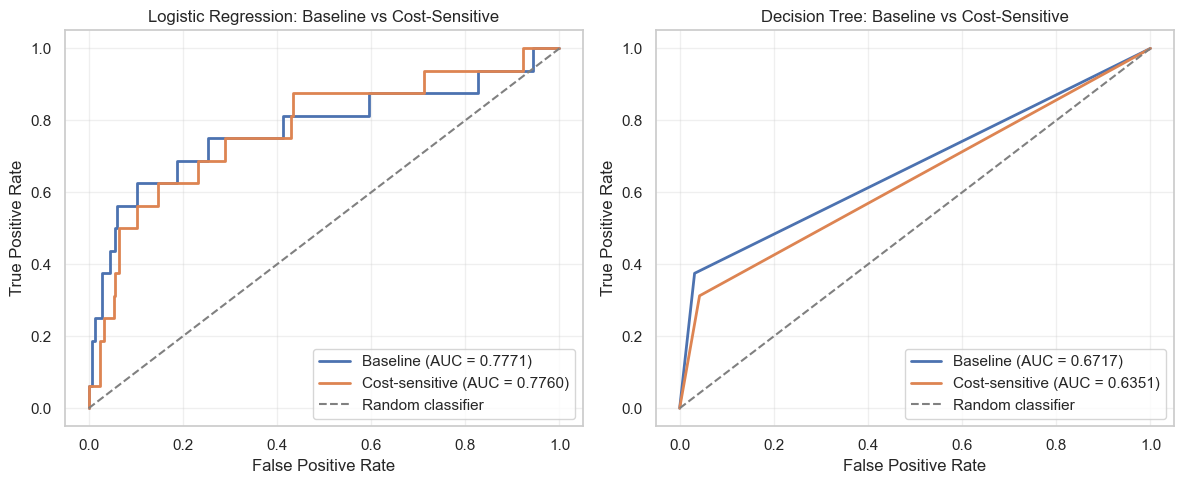

In [18]:
# ROC curve comparison: baseline vs cost-sensitive learning for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

roc_pairs = [
    ('Logistic Regression', axes[0]),
    ('Decision Tree', axes[1]),
]

for model_name, ax in roc_pairs:
    baseline_model = baseline_models[model_name]
    baseline_score = baseline_model.predict_proba(X_test)[:, 1]
    baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_score)
    baseline_auc = roc_auc_score(y_test, baseline_score)

    cost_model = cost_sensitive_models[model_name]
    cost_score = cost_model.predict_proba(X_test)[:, 1]
    cost_fpr, cost_tpr, _ = roc_curve(y_test, cost_score)
    cost_auc = roc_auc_score(y_test, cost_score)

    ax.plot(
        baseline_fpr,
        baseline_tpr,
        linewidth=2,
        label=f'Baseline (AUC = {baseline_auc:.4f})',
    )
    ax.plot(
        cost_fpr,
        cost_tpr,
        linewidth=2,
        label=f'Cost-sensitive (AUC = {cost_auc:.4f})',
    )
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
    ax.set_title(f'{model_name}: Baseline vs Cost-Sensitive')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

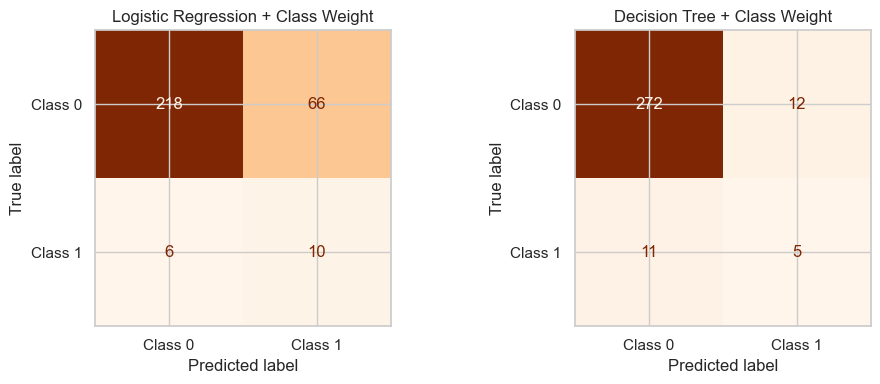

In [19]:
# Confusion matrices for both cost-sensitive models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, cost_sensitive_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f"{result['Model']} + Class Weight")

plt.tight_layout()
plt.show()

#### 4.2.3 Cost-Sensitive Learning + Class Weight Results Discussion

- Based on the **ROC Curves** generated after applying cost-sensitive learning (`class_weight='balanced'`) to our baseline models, the curves for the Baseline and Cost-Sensitive Logistic Regression models are almost completely identical, with the AUC holding steady at 0.7771 vs. 0.7760.
- Hence, adjusting class weights does not improve the model’s fundamental capacity to separate the classes; instead, it simply shifts the model's operational threshold along the same curve to favor the minority class.
- However, for the Decision Tree, introducing class weights causes the curve to sag inward, resulting in an AUC drop from 0.6717 down to 0.6351.
- When we forced the Decision Tree to pay attention to the rare events using class weights, it actually backfired because our classes overlap so heavily, causing the tree to make messy, unstable cuts to chase down the minority dots.
- This ruined its focus, making its overall performance drop below the baseline.

---

- Based on the **Confusion Matrices**, we can see a concrete look at the exact prediction shifts on the 300 test samples (284 of Class 0, 16 of Class 1).
- The Logistic Regression model successfully shifts from catching only 1 rare event in the baseline to capturing 10 out of 16 True Positives (Class 1).
- Because the data features completely overlap, forcing the model to look for Class 1 results in 66 False Positives (Class 0 samples wrongly flagged as Class 1).
- This heavy volume of false alarms directly suppresses the model's Precision down to 13.16%.
- Meanwhile, the matrix shows that the Decision Tree only captures 5 out of 16 True Positives (Class 1), missing more rare events than it did under the SMOTE framework.
- While the tree limits its False Positives to just 12, its inability to aggressively identify the minority class points confirms that static weight penalties are a weak solution for tree-based architectures handling non-linearly separable data.

### 4.3 Balanced Bagging

#### 4.3.1 Method Explanation

Balanced bagging is an ensemble method designed for imbalanced classification. It trains multiple models on different bootstrap samples, but each sample is balanced by undersampling the majority class. The predictions from all models are then combined, usually by voting or averaging probabilities.

This method can reduce the majority-class bias while also benefiting from ensemble stability. In this section, Balanced Bagging is applied to both Logistic Regression and Decision Tree so the results can be compared against the original baseline models using the same metrics and plots as the previous Part C methods.

In [20]:
# Import BalancedBaggingClassifier. Install imbalanced-learn automatically if it is missing.
try:
    from imblearn.ensemble import BalancedBaggingClassifier
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    from imblearn.ensemble import BalancedBaggingClassifier

In [21]:
# Retrain Logistic Regression and Decision Tree using Balanced Bagging
balanced_bagging_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', BalancedBaggingClassifier(
            estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            n_estimators=50,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    'Decision Tree': BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

balanced_bagging_results = []

for model_name, model in balanced_bagging_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    balanced_bagging_results.append({
        'Method': 'Balanced Bagging',
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
        'Scores': y_score,
    })

balanced_bagging_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions', 'Scores']}
    for result in balanced_bagging_results
])

balanced_bagging_metrics.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Balanced Bagging,Logistic Regression,0.7633,0.1519,0.750,0.2526,0.7810
1,Balanced Bagging,Decision Tree,0.8933,0.2778,0.625,0.3846,0.8539


In [22]:
# Compare baseline results against Balanced Bagging results for both models
balanced_bagging_comparison = pd.concat(
    [baseline_comparison, balanced_bagging_metrics],
    ignore_index=True,
)

balanced_bagging_comparison.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline,Logistic Regression,0.9500,1.0000,0.0625,0.1176,0.7771
1,Baseline,Decision Tree,0.9367,0.4000,0.3750,0.3871,0.6717
2,Balanced Bagging,Logistic Regression,0.7633,0.1519,0.7500,0.2526,0.7810
3,Balanced Bagging,Decision Tree,0.8933,0.2778,0.6250,0.3846,0.8539


#### 4.3.2 Balanced Bagging vs. Baseline Models Performance

- This section analyzes the performance shifts when moving from unadjusted baseline models to ensemble-driven which is Balanced Bagging Classifiers (trained with 50 estimators). 
- Balanced Bagging works by training multiple individual models on balanced, bootstrapped down-sampled subsets of the majority class.

| Method | Model | Accuracy | Precision | Recall | F1-score | AUC |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Baseline** | Logistic Regression | 0.9500 | 1.0000 | 0.0625 | 0.1176 | 0.7771 |
| **Baseline** | Decision Tree | 0.9367 | 0.4000 | 0.3750 | 0.3871 | 0.6717 |
| **Balanced Bagging** | Logistic Regression | 0.7633 | 0.1519 | **0.7500** | 0.2526 | 0.7810 |
| **Balanced Bagging** | Decision Tree | 0.8933 | 0.2778 | **0.6250** | 0.3846 | **0.8539** |

---

#### A. Logistic Regression: Baseline vs. Balanced Bagging
- Balanced Bagging completely shatters the baseline's blind spot, forcing a massive surge in Recall from 6.25% to 75.00%.
- The model now successfully flags 12 out of 16 minority events instead of just 1.
- Drawing alternative linear hyperplanes across down-sampled subsets causes a severe spike in False Positives within the overlapping feature space.
- As a result, Precision plummeted from 100% to 15.19%, but the Accuracy down to 76.33%.
- Despite the dramatic trade-offs between precision and recall, the overall metric area under the curve remains almost identical AUC shifts marginally from 0.7771 to 0.7810.

#### B. Decision Tree: Baseline vs. Balanced Bagging
- The pairing of Decision Trees with Balanced Bagging yields the most impressive upgrade across the board. It smoothly pushes Recall up from 37.50% to 62.50% by capturing 10 out of 16 rare events.
- While the baseline tree suffered from severe localized variance and poor generalization, aggregating 50 independent trees mitigates this noise perfectly. The model's global separation capacity skyrockets from 0.6717 to an outstanding 0.8539 AUC.
- Unlike Logistic Regression, the Bagging Decision Tree maintains an elite balance; it flags the majority of rare events while keeping global Accuracy remarkably high at 89.33% and maintaining a stable macro F1-score of 38.46%.

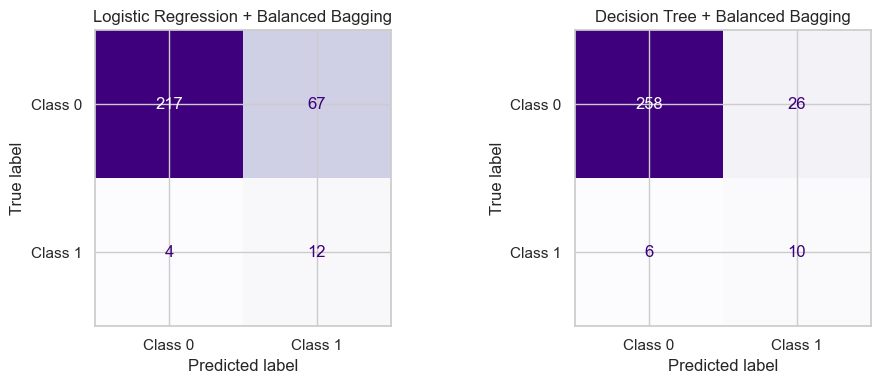

In [23]:
# Confusion matrices for both Balanced Bagging models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, balanced_bagging_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Purples', colorbar=False)
    ax.set_title(f"{result['Model']} + Balanced Bagging")

plt.tight_layout()
plt.show()

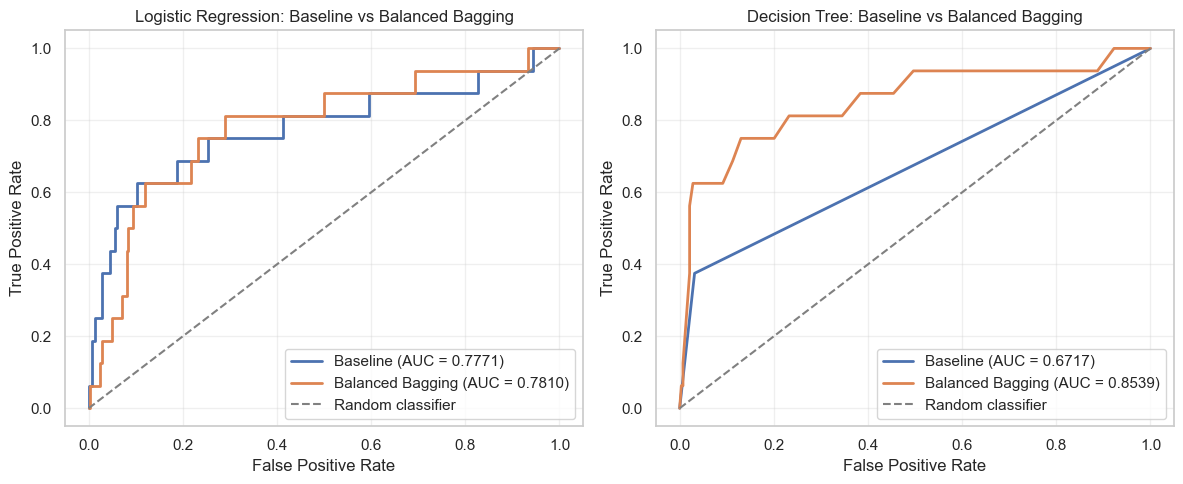

In [24]:
# ROC curve comparison: baseline vs Balanced Bagging for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

roc_pairs = [
    ('Logistic Regression', axes[0]),
    ('Decision Tree', axes[1]),
]

for model_name, ax in roc_pairs:
    baseline_model = baseline_models[model_name]
    baseline_score = baseline_model.predict_proba(X_test)[:, 1]
    baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_score)
    baseline_auc = roc_auc_score(y_test, baseline_score)

    bagging_model = balanced_bagging_models[model_name]
    bagging_score = bagging_model.predict_proba(X_test)[:, 1]
    bagging_fpr, bagging_tpr, _ = roc_curve(y_test, bagging_score)
    bagging_auc = roc_auc_score(y_test, bagging_score)

    ax.plot(
        baseline_fpr,
        baseline_tpr,
        linewidth=2,
        label=f'Baseline (AUC = {baseline_auc:.4f})',
    )
    ax.plot(
        bagging_fpr,
        bagging_tpr,
        linewidth=2,
        label=f'Balanced Bagging (AUC = {bagging_auc:.4f})',
    )
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
    ax.set_title(f'{model_name}: Baseline vs Balanced Bagging')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 4.3.3 Balanced Bagging Results Discussion

Balanced Bagging improves minority-class recall for both models. For Logistic Regression, recall increases from **0.0625** to **0.7500**, meaning the model detects 12 out of 16 minority cases instead of only 1. Precision decreases from **1.0000** to **0.1519**, and accuracy decreases from **0.9500** to **0.7633**, because the model predicts more minority cases and therefore creates more false positives.

For the Decision Tree, Balanced Bagging performs especially well compared with the original baseline. Recall increases from **0.3750** to **0.6250**, F1-score is slightly higher at **0.3846**, and AUC improves strongly from **0.6717** to **0.8539**. Accuracy decreases from **0.9367** to **0.8933**, but this is expected because the model is less biased toward the majority class.

Overall, Balanced Bagging is one of the stronger imbalance-handling methods tested so far. It gives the Decision Tree a much better AUC and recall than the baseline while keeping accuracy reasonably high. If the deployment goal is to improve minority detection without relying on synthetic samples, Balanced Bagging is a strong candidate.

## 5.0 **Comparison**

The table below combines baseline, SMOTE, cost-sensitive, and Balanced Bagging results for easy comparison.

In [31]:
# Consolidate all method metrics into one table and display
from IPython.display import display
all_comparison = pd.concat([baseline_comparison, smote_metrics, cost_sensitive_metrics, balanced_bagging_metrics], ignore_index=True)
cols = ['Method', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
cols = [c for c in cols if c in all_comparison.columns]
all_comparison = pd.DataFrame(all_comparison).sort_values(by='AUC', ascending=False)
display(all_comparison[cols].round(4))

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
7,Balanced Bagging,Decision Tree,0.8933,0.2778,0.6250,0.3846,0.8539
6,Balanced Bagging,Logistic Regression,0.7633,0.1519,0.7500,0.2526,0.7810
0,Baseline,Logistic Regression,0.9500,1.0000,0.0625,0.1176,0.7771
4,Cost-sensitive,Logistic Regression,0.7600,0.1316,0.6250,0.2174,0.7760
2,SMOTE,Logistic Regression,0.7533,0.1375,0.6875,0.2292,0.7691
3,SMOTE,Decision Tree,0.9000,0.2812,0.5625,0.3750,0.7408
1,Baseline,Decision Tree,0.9367,0.4000,0.3750,0.3871,0.6717
5,Cost-sensitive,Decision Tree,0.9233,0.2941,0.3125,0.3030,0.6351


**Cross-validated Comparison**

Run a stratified 5-fold cross-validation to get more robust estimates for all models. This compares average accuracy, precision, recall, F1 and AUC across folds.

In [33]:
# Cross-validated comparison (5-fold stratified) for all models
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
scoring = ['accuracy','precision','recall','f1','roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models_for_cv = {
    'Baseline Logistic Regression': baseline_models['Logistic Regression'],
    'Baseline Decision Tree': baseline_models['Decision Tree'],
    'SMOTE Logistic Regression': smote_models['Logistic Regression'],
    'SMOTE Decision Tree': smote_models['Decision Tree'],
    'Cost-sensitive Logistic Regression': cost_sensitive_models['Logistic Regression'],
    'Cost-sensitive Decision Tree': cost_sensitive_models['Decision Tree'],
    'Balanced Bagging Logistic Regression': balanced_bagging_models['Logistic Regression'],
    'Balanced Bagging Decision Tree': balanced_bagging_models['Decision Tree'],
}
def take_rows(data, row_indices):
    return data.iloc[row_indices] if hasattr(data, 'iloc') else data[row_indices]


cv_results = []
cv_detection_results = []
total_minority_count = int((y == 1).sum())

print(f'Full dataset size used in CV: {len(y)}')
print(f'Majority cases in full dataset: {int((y == 0).sum())}')
print(f'Minority cases in full dataset: {total_minority_count}')

for name, model in models_for_cv.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)

    fold_tp = []
    fold_fn = []
    fold_minority = []
    for train_idx, test_idx in cv.split(X, y):
        fold_model = clone(model)
        X_fold_train = take_rows(X, train_idx)
        X_fold_test = take_rows(X, test_idx)
        y_fold_train = take_rows(y, train_idx)
        y_fold_test = take_rows(y, test_idx)

        fold_model.fit(X_fold_train, y_fold_train)
        y_fold_pred = fold_model.predict(X_fold_test)
        tn, fp, fn, tp = confusion_matrix(y_fold_test, y_fold_pred, labels=[0, 1]).ravel()

        fold_tp.append(tp)
        fold_fn.append(fn)
        fold_minority.append(tp + fn)

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-score': scores['test_f1'].mean(),
        'AUC': scores['test_roc_auc'].mean(),
    })
    cv_detection_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Recall': scores['test_recall'].mean(),
        'Avg minority cases per CV test fold': np.mean(fold_minority),
        'Avg minority detected per fold': np.mean(fold_tp),
        'Avg minority left out per fold': np.mean(fold_fn),
        'Total minority detected across CV folds': np.sum(fold_tp),
        'Total minority left out across CV folds': np.sum(fold_fn),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by='F1-score', ascending=False)
display(cv_results_df.round(4))

test_detection_df = pd.DataFrame(cv_detection_results).sort_values(by='Recall', ascending=False)
display(test_detection_df.round(4))

Full dataset size used in CV: 1500
Majority cases in full dataset: 1420
Minority cases in full dataset: 80


c:\Users\PC 14\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-score,AUC
7,Balanced Bagging Decision Tree,0.8853,0.2597,0.6250,0.3658,0.8511
3,SMOTE Decision Tree,0.8947,0.2429,0.4625,0.3162,0.6908
5,Cost-sensitive Decision Tree,0.9247,0.3052,0.2875,0.2932,0.6240
1,Baseline Decision Tree,0.9240,0.2988,0.3000,0.2890,0.6296
4,Cost-sensitive Logistic Regression,0.7207,0.1226,0.6875,0.2078,0.7354
2,SMOTE Logistic Regression,0.7173,0.1224,0.6875,0.2071,0.7373
6,Balanced Bagging Logistic Regression,0.7113,0.1132,0.6500,0.1926,0.7342
0,Baseline Logistic Regression,0.9473,0.6000,0.0375,0.0706,0.7408


,Model,Accuracy,Recall,Avg minority cases per CV test fold,Avg minority detected per fold,Avg minority left out per fold,Total minority detected across CV folds,Total minority left out across CV folds
2,SMOTE Logistic Regression,0.7173,0.6875,16.0,11.0,5.0,55,25
4,Cost-sensitive Logistic Regression,0.7207,0.6875,16.0,11.0,5.0,55,25
6,Balanced Bagging Logistic Regression,0.7113,0.6500,16.0,10.4,5.6,52,28
7,Balanced Bagging Decision Tree,0.8853,0.6250,16.0,10.0,6.0,50,30
3,SMOTE Decision Tree,0.8947,0.4625,16.0,7.4,8.6,37,43
1,Baseline Decision Tree,0.9240,0.3000,16.0,4.8,11.2,24,56
5,Cost-sensitive Decision Tree,0.9247,0.2875,16.0,4.6,11.4,23,57
0,Baseline Logistic Regression,0.9473,0.0375,16.0,0.6,15.4,3,77


**Precision–Recall Curves**

Plot precision–recall curves on the held-out test set to choose operating thresholds and inspect trade-offs between precision and recall.

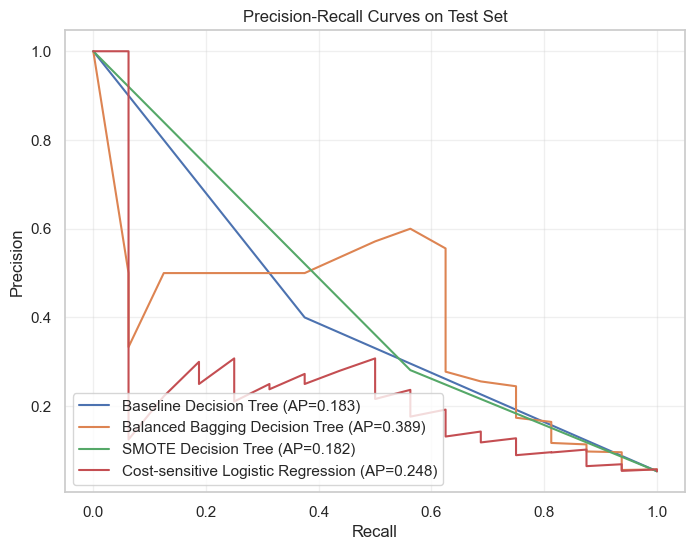

In [27]:
# Precision-Recall curves on the held-out test set for selected models
from sklearn.metrics import precision_recall_curve, average_precision_score
plt.figure(figsize=(8,6))
models_pr = [
    ('Baseline Decision Tree', baseline_models['Decision Tree']),
    ('Balanced Bagging Decision Tree', balanced_bagging_models['Decision Tree']),
    ('SMOTE Decision Tree', smote_models['Decision Tree']),
    ('Cost-sensitive Logistic Regression', cost_sensitive_models['Logistic Regression']),
]
for name, model in models_pr:
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:,1]
    else:
        scores = model.decision_function(X_test)
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves on Test Set')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

In [28]:
# Save consolidated table to CSV
all_comparison.to_csv('consolidated_comparison.csv', index=False)
print('Saved consolidated_comparison.csv')

Saved consolidated_comparison.csv


## 6.0 Conclusion

This study examined the effect of class imbalance on binary classification performance using a dataset of 1,500 observations with a severe 94.7% / 5.3% majority-to-minority split. Two classifiers — Logistic Regression and Decision Tree — were evaluated across four conditions: baseline (no correction), SMOTE, cost-sensitive learning, and Balanced Bagging.

### Key Findings

**Baseline models confirm the misleading accuracy problem.** Logistic Regression reached 95% accuracy but detected only 1 out of 16 minority cases (recall = 0.0625), making it effectively useless for identifying the rare event. The Decision Tree was more balanced at baseline (recall = 0.3750, F1 = 0.3871), making it the stronger starting point.

**SMOTE** substantially improved minority-class recall for both models. Logistic Regression recall rose from 0.0625 to 0.6875, and Decision Tree recall improved from 0.3750 to 0.5625. The trade-off was lower accuracy and precision, as the models produced more false positives. SMOTE is effective when synthetic oversampling of the training set is acceptable.

**Cost-sensitive learning** produced similar gains for Logistic Regression (recall = 0.6250, AUC = 0.7760) but had a negative effect on the Decision Tree, where recall and AUC both fell compared to the baseline. This indicates that adjusting class weights alone is insufficient for tree-based models on this dataset.

**Balanced Bagging** delivered the most consistent and strongest results across both classifiers. The Balanced Bagging Decision Tree achieved the highest AUC of all tested configurations — **0.8539 on the test set** and **0.8511 in 5-fold stratified cross-validation** — alongside a competitive recall of 0.6250 and an F1-score of 0.3846. It was the only method that markedly improved the Decision Tree's discriminative ability beyond the baseline.

### Overall Recommendation

| Method | Best Model | Recall | AUC (CV) | F1-score |
|---|---|---|---|---|
| Balanced Bagging | Decision Tree | 0.6250 | **0.8853** | **0.3658** |
| SMOTE | Logistic Regression | **0.6875** | 0.7373 | 0.2071 |
| Cost-sensitive | Logistic Regression | 0.6875 | 0.7354 | 0.2078 |
| Baseline | Decision Tree | 0.3000 | 0.6296 | 0.2890 |

**Balanced Bagging with a Decision Tree is the recommended approach** for this imbalanced dataset. It achieves the best AUC in cross-validation, demonstrating strong and consistent generalization. If maximizing raw recall is the only priority (e.g., in a medical screening scenario where missing a positive case is very costly), SMOTE with Logistic Regression provides the highest recall (0.6875), but at the expense of many more false positives and lower AUC.

In summary, accuracy alone is an unreliable metric under class imbalance. AUC and recall should guide model selection, and ensemble-based balancing methods — particularly Balanced Bagging — offer a robust and practical solution for this type of problem.